In [685]:
import pandas as pd
import csv
import matplotlib.pyplot as plt

In [758]:
import csv

with open("Sales_2021-2023-Raw-data(1).csv", encoding="ISO-8859-1") as f:
    reader = csv.reader(f)
    data = [row for row in reader]

print("Total rows read:", len(data))


Total rows read: 11556


In [759]:

df = pd.read_csv(
    "Sales_2021-2023-Raw-data(1).csv",
    encoding="ISO-8859-1",
    engine="python",   # less strict about delimiters
    sep=",",
    on_bad_lines="warn"  # warns instead of skipping
)

In [760]:
df = df[["Document Date", "Document Type", "Item Class", "Quantity", "Sales", "Profit"]]

In [761]:
df.head(10)

,Document Date,Document Type,Item Class,Quantity,Sales,Profit
0,4/30/2021,INVOICE,SP,6,410.7,399.72
1,4/30/2021,INVOICE,SP,12,58.08,29.54
2,5/3/2021,INVOICE,SP,1,94.48,53.31
3,5/3/2021,INVOICE,SP,1,50.33,37.15
4,5/3/2021,INVOICE,SP,1,53.63,40.41
5,5/26/2021,INVOICE,SP,1,88,19.93
6,5/26/2021,INVOICE,SP,2,130.2,-87.8
7,11/22/2021,INVOICE,SP,1,80.82,67.64
8,5/10/2022,INVOICE,SP,4,481.52,129.8
9,5/10/2022,INVOICE,SP,2,26.46,13.46


Filtering the data.

Converting the date column to datetime.

In [762]:
reduced_df.loc[:, "Document Date"] = pd.to_datetime(reduced_df["Document Date"])

In [763]:
df["Quantity"] = (
    df["Quantity"]
    .replace(",", "", regex=True)    # remove thousands separators
    .replace(r"[^0-9.\-]", "", regex=True)  # remove any letters or stray symbols
    .replace("", 0, regex=True)
)


Dropping all the 

In [764]:
df["Quantity"] = df["Quantity"].replace(",", "", regex=True).astype(float)

In [765]:
df["Quantity"].sum()

np.float64(8123793.03)

In [766]:
#filtered_df = reduced_df.dropna(subset=["Document Date"])
df = df.dropna(subset=["Quantity"])

In [697]:
df["Quantity"].sum()

np.float64(8123793.03)

Sorting the data

In [767]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

In [768]:
# 1️⃣ Convert to string
#df["YearMonth"] = df["YearMonth"].astype(str)

# 2️⃣ Extract only the first date (before the "/")
#df["YearMonth"] = df["YearMonth"].str.split("/").str[0]

# 3️⃣ Convert it back to datetime
#df["YearMonth"] = pd.to_datetime(df["YearMonth"])
df["Quantity"].sum()

np.float64(8123793.03)

In [769]:
df = df.sort_values(by="Document Date", ascending=True)

In [755]:
df = df.reset_index(drop=True)

Grouping the data by months

In [770]:
# Convert to datetime
df["Document Date"] = pd.to_datetime(df["Document Date"])

# Group by month and sum quantities
df = df.groupby(pd.Grouper(key="Document Date", freq="MS"))["Quantity"].sum().reset_index()

# Rename columns for Prophet
df.rename(columns={"Document Date": "ds", "Quantity": "y"}, inplace=True)

# Check result
df.head()


,ds,y
0,2021-01-01,41482.00
1,2021-02-01,147270.16
2,2021-03-01,270890.00
3,2021-04-01,137395.78
4,2021-05-01,26159.40


In [703]:
df["Quantity"] = df["Quantity"].abs()
df["Quantity"].sum()

np.float64(8123793.029999999)

In [704]:
df = df[["YearMonth", "Quantity"]]

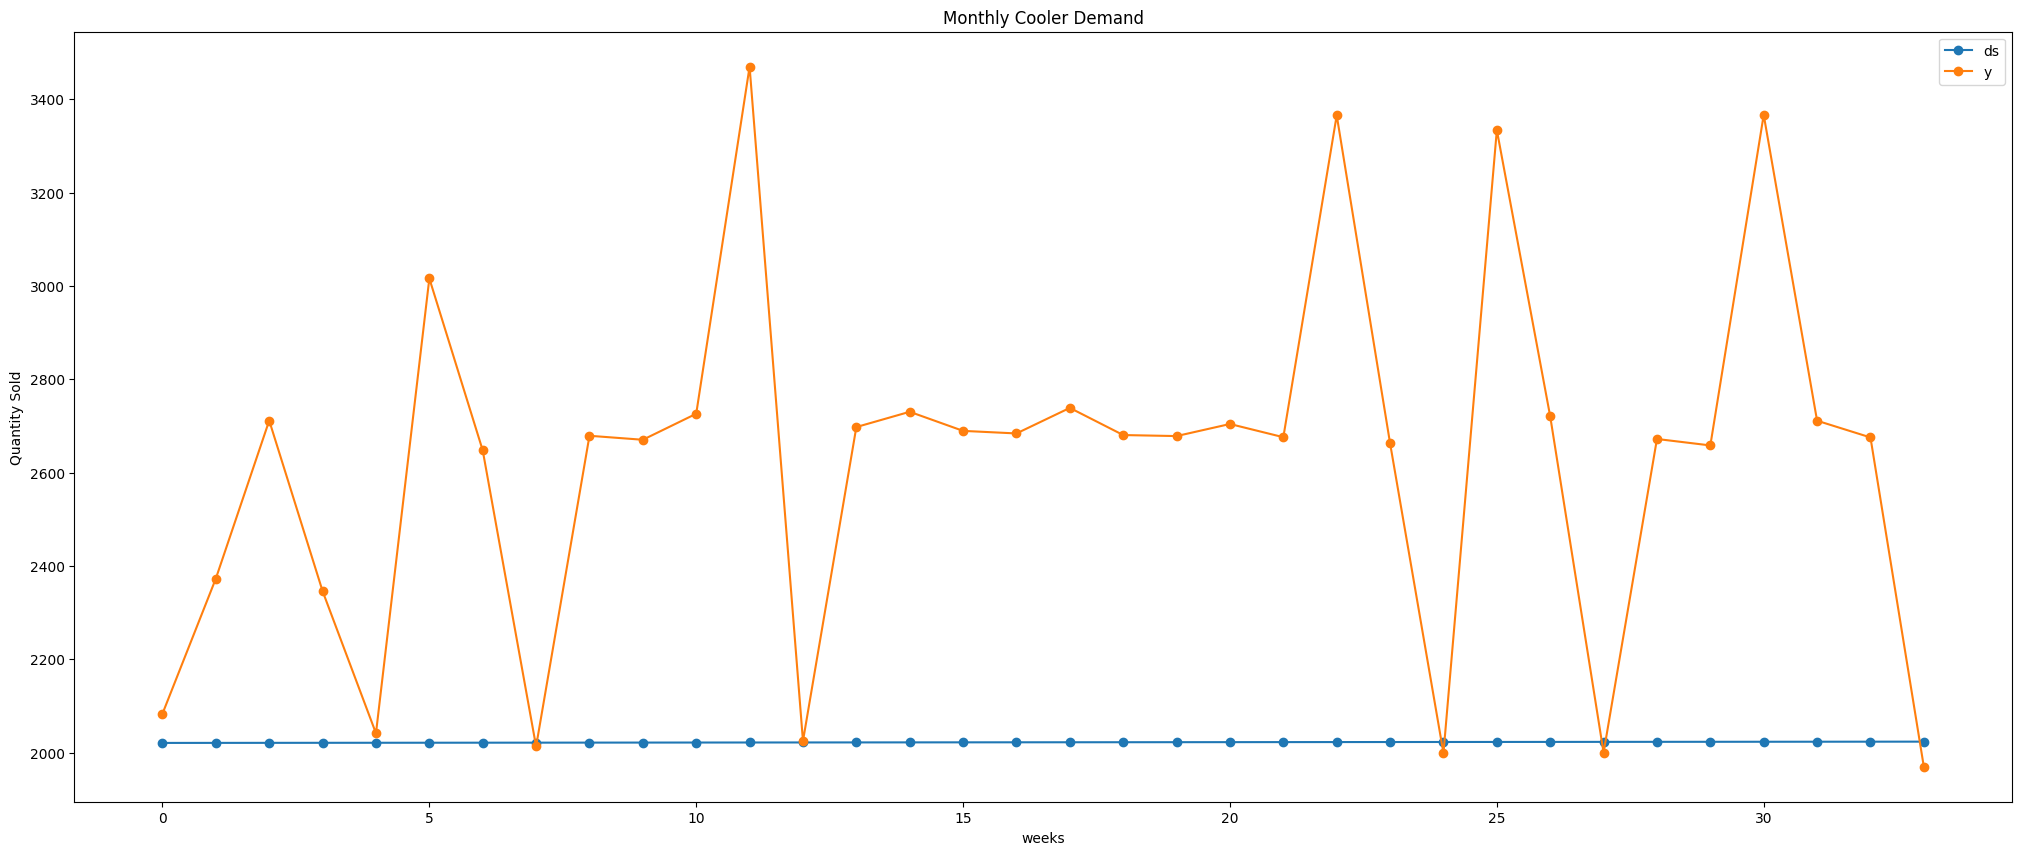

In [771]:
df.plot(kind="line", marker="o", title="Monthly Cooler Demand", figsize=(25, 10))
plt.xlabel("weeks")
plt.ylabel("Quantity Sold")
plt.show()

In [772]:
df.columns = ["ds", "y"]
df["ds"] = df["ds"].astype(str)
df["ds"] = df["ds"].str.split('/').str[0]
#new_df = new_df.dropna(subset=["ds", "y"])
#new_df["ds"] = pd.to_datetime(new_df["ds"], errors="coerce")

In [480]:
#df["ds"] = pd.to_datetime(new_df["ds"], errors="coerce")
#df = df.dropna(subset=["ds", "y"]) 
#df.to_csv("Oringinal weekly data before fitting into the model.csv") 

In [781]:
df = df[df['y'].notna()]
df["y"].sum()
#df.to_csv("I really wanna see.csv")

np.float64(8123793.029999999)

In [867]:
df['y'].describe()

count        34.000000
mean     238935.089118
std      146205.132215
min           1.000000
25%      172343.870000
50%      258887.140000
75%      273336.575000
max      547827.380000
Name: y, dtype: float64

Prophet

In [802]:
from prophet import Prophet

In [860]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    seasonality_mode='multiplicative',  # works better for sales data
    changepoint_prior_scale=0.3         # allows more flexibility in trend changes
)

Fitting the values into the model

In [862]:
model.fit(df)

14:31:11 - cmdstanpy - INFO - Chain [1] start processing
14:31:11 - cmdstanpy - INFO - Chain [1] done processing


**Making Future Dates in Prophet**

In [863]:
future_dates = model.make_future_dataframe(periods=12, freq="QE") 

In [843]:
df["y"].sum()

np.float64(8123793.029999999)

In [864]:
predictions = model.predict(future_dates)

In [727]:
excel_data = predictions.to_csv("Monthly forecast from prophet after fitting into the model.csv")

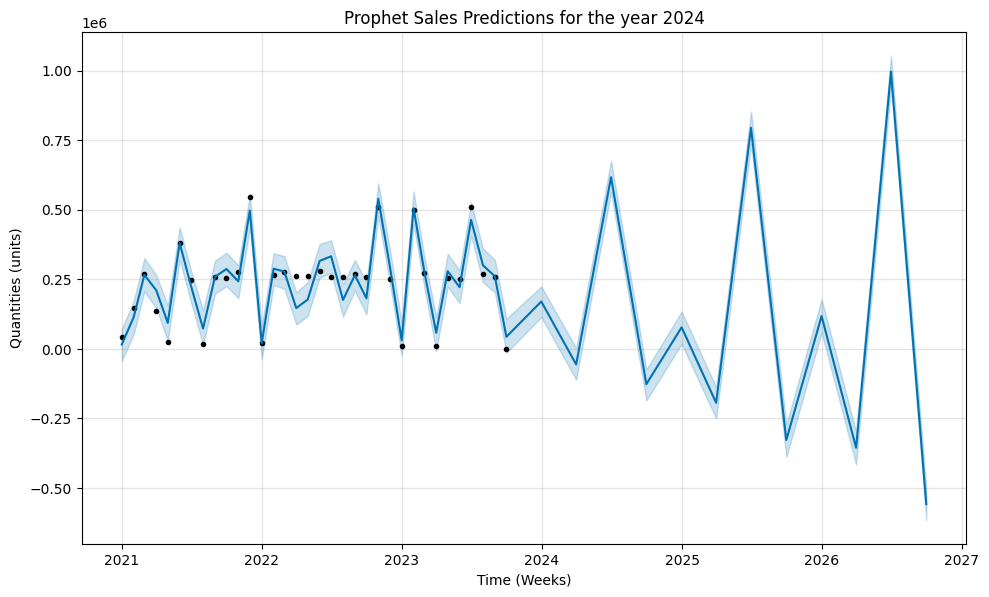

In [865]:
model.plot(predictions)
plt.title("Prophet Sales Predictions for the year 2024")
plt.xlabel("Time (Months)")
plt.ylabel("Quantities (units)")
plt.show()

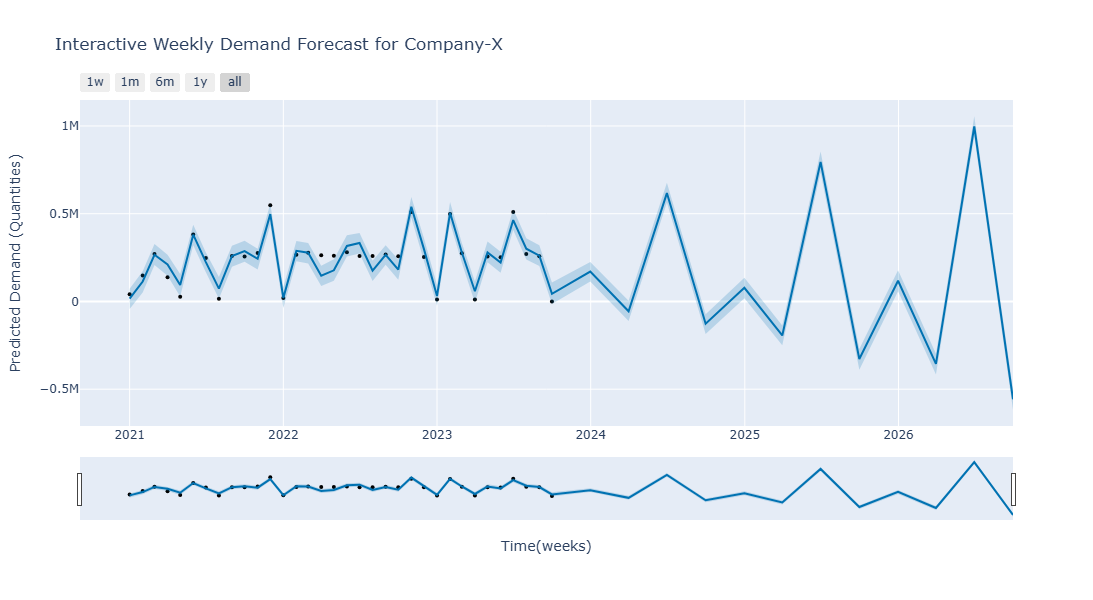

In [866]:
from prophet.plot import plot_plotly

fig = plot_plotly(model, predictions)
fig.update_layout(
    title="Interactive Weekly Demand Forecast for Company-X",
    xaxis_title="Time(weeks)",
    yaxis_title="Predicted Demand (Quantities)",
)
fig.show()

Transferring the model predictions to a csv file

In [ ]:
predictions.to_csv("Prophet_Forecast_Results.csv", index=False)

Visualize each component

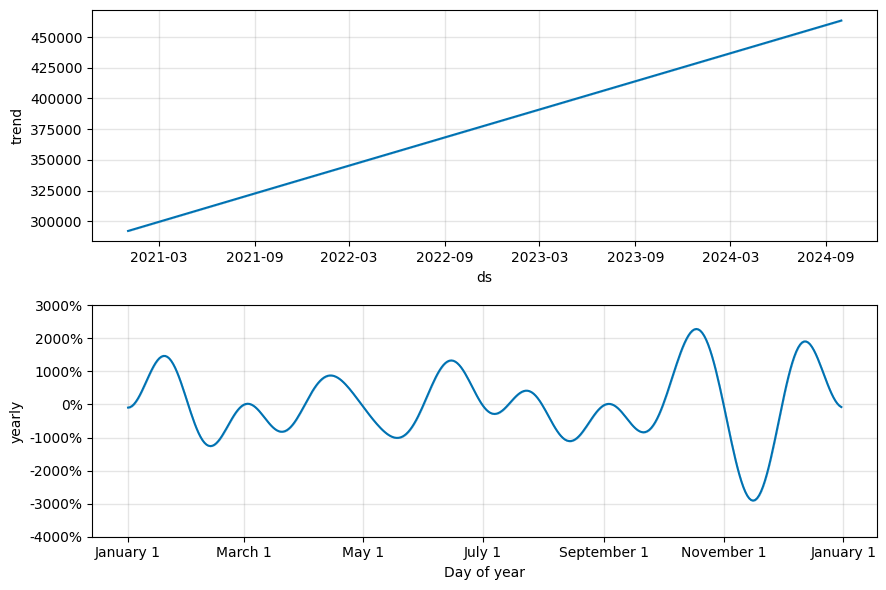

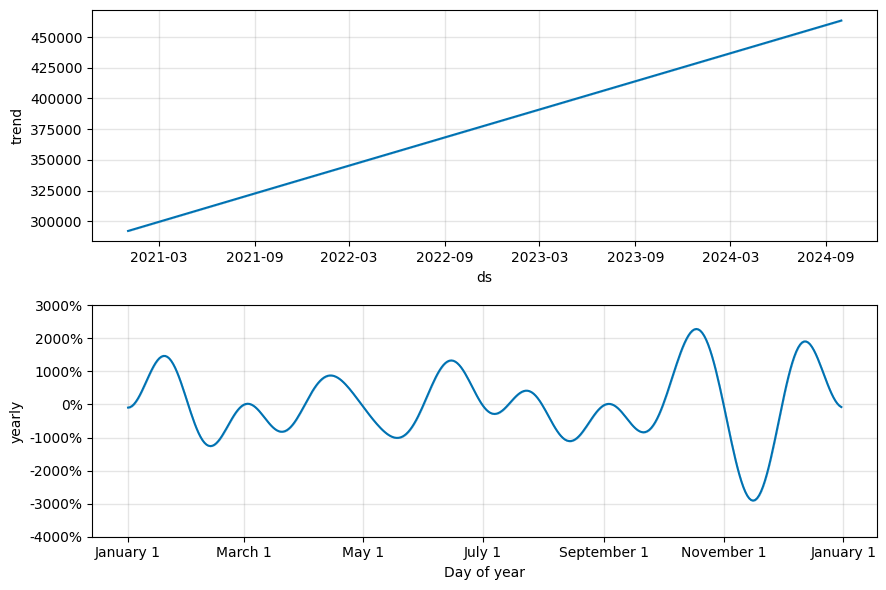

In [825]:
model.plot_components(predictions)

Cross Validation

In [826]:
from prophet.diagnostics import cross_validation

In [829]:
df_cv = cross_validation(model, initial='730 days', period='90 days', horizon='180 days')
#excel = df_cv.to_csv("cross-validation values.csv")

  0%|                                                                     | 0/2 [00:00<?, ?it/s]14:05:39 - cmdstanpy - INFO - Chain [1] start processing
14:06:15 - cmdstanpy - INFO - Chain [1] done processing
 50%|██████████████████████████████▌                              | 1/2 [00:36<00:36, 36.23s/it]14:06:15 - cmdstanpy - INFO - Chain [1] start processing
14:06:16 - cmdstanpy - INFO - Chain [1] done processing
100%|█████████████████████████████████████████████████████████████| 2/2 [00:36<00:00, 18.36s/it]


In [830]:
from prophet.diagnostics import performance_metrics

In [831]:
df_P = performance_metrics(df_cv)

In [832]:
df_P.head(5)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,27 days,4.829825e+10,219768.625876,219768.625876,0.856814,0.856814,0.599839,0.0
1,28 days,3.962347e+10,199056.439309,199056.439309,0.399501,0.399501,0.499221,0.0
2,56 days,1.752605e+10,132385.985582,132385.985582,0.482892,0.482892,0.636596,0.0
3,58 days,3.927352e+10,198175.485578,198175.485578,0.788137,0.788137,1.300703,0.0
4,87 days,3.705006e+10,192483.911621,192483.911621,17.466780,17.466780,1.794522,0.0


In [ ]:
df_P.tail(10)

Plotting the cross validation metrics RMSE

In [833]:
from prophet.plot import plot_cross_validation_metric

C:\Users\GIBSON MZIMANDE\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:547: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.

C:\Users\GIBSON MZIMANDE\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:548: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



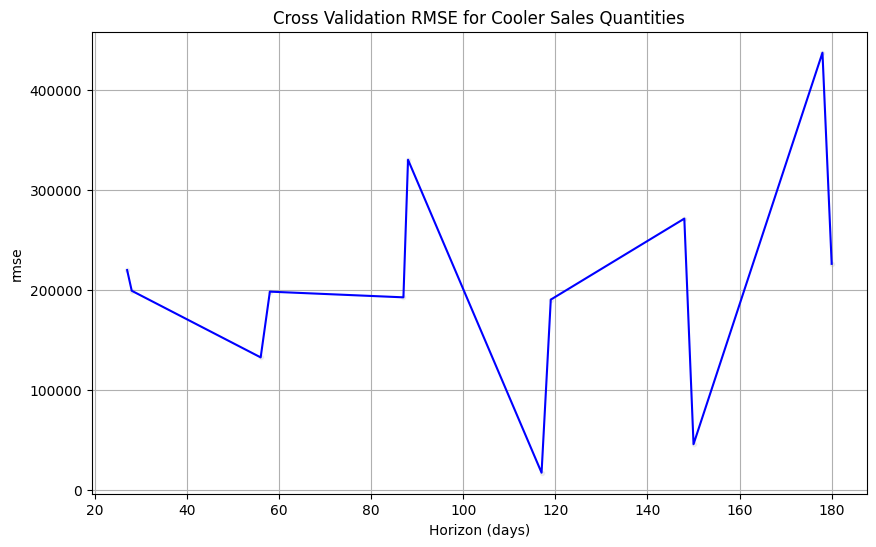

In [834]:
fig = plot_cross_validation_metric(df_cv, metric='rmse')

plt.title("Cross Validation RMSE for Cooler Sales Quantities")
plt.show()